In [170]:
import numpy as np    
import pandas as pd   
import matplotlib.pyplot as plt  
%matplotlib inline
import seaborn as sns  

In [171]:
# Read the Diwali Sales dataset with appropriate encoding to handle special characters
df = pd.read_csv('Diwali Sales Data.csv', encoding = 'unicode_escape')
df.shape

(11251, 15)

In [172]:
# Display the first 2 rows of the dataset to preview the data structure and contents
df.head(2)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN


In [173]:
# Display summary information about the dataset including column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [174]:
# Drop unnecessary columns 'Status' and 'unnamed1' from the dataset to clean the data
df.drop(['Status','unnamed1'], axis=1, inplace=True)

In [175]:
# To show all the columns in our Dataset
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [176]:
# To findout all Null values
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [177]:
df.shape

(11251, 13)

In [178]:
# Drop null values
df.dropna(inplace=True)

In [179]:
df.shape

(11239, 13)

In [180]:
# Convert the 'Amount' column to integer type for numerical operations
df['Amount'] = df['Amount'].astype('int')

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   User_ID           11239 non-null  int64 
 1   Cust_name         11239 non-null  object
 2   Product_ID        11239 non-null  object
 3   Gender            11239 non-null  object
 4   Age Group         11239 non-null  object
 5   Age               11239 non-null  int64 
 6   Marital_Status    11239 non-null  int64 
 7   State             11239 non-null  object
 8   Zone              11239 non-null  object
 9   Occupation        11239 non-null  object
 10  Product_Category  11239 non-null  object
 11  Orders            11239 non-null  int64 
 12  Amount            11239 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 1.2+ MB


In [182]:
# display as Heading
from IPython.display import display, HTML
display(HTML("<h1>Diwali Sales Analysis</h1>"))
display(HTML("<h2>Gender</h2>"))

In [183]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

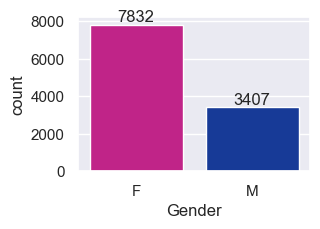

In [185]:
# Define colors
colors = ['#da0a8f', '#0231ac']

# Create countplot
ax = sns.countplot(x='Gender', data=df, hue='Gender', palette=colors)
sns.set(rc={'figure.figsize': (3,2)})

# Add bar labels
for bars in ax.containers:
    ax.bar_label(bars)

In [186]:
df.groupby(['Gender'], as_index= False)['Amount'].sum().sort_values(by='Amount', ascending= False)

,Gender,Amount
0,F,74335853
1,M,31913276


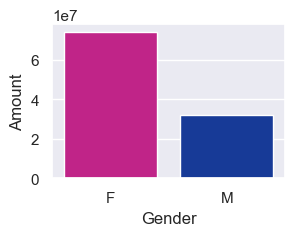

In [188]:
# Sales by gender on the basis of total Amount
Sales_by_Gen = df.groupby(['Gender'], as_index= False)['Amount'].sum().sort_values(by='Amount', ascending= False)
sns.barplot(x='Gender', y='Amount', data=Sales_by_Gen,hue='Gender', palette= colors)
sns.set(rc={'figure.figsize': (3,2)})

_**From above Graphs we can see that most of the Buyers are Females.**_

In [189]:
# To display Sub-Heading
display(HTML("<h2>Age</h2>"))

In [190]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

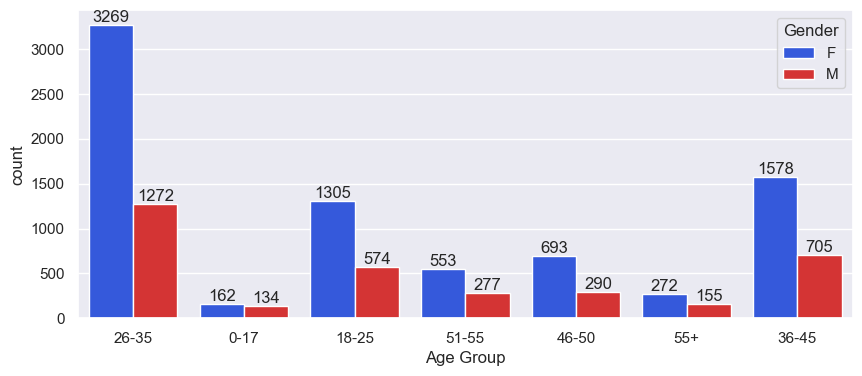

In [194]:
colors = ['#1a49f6', '#ef1919']
ax = sns.countplot(x= 'Age Group', data= df, hue='Gender',palette= colors)
sns.set(rc={'figure.figsize': (10,4)})
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Age Group', ylabel='Amount'>

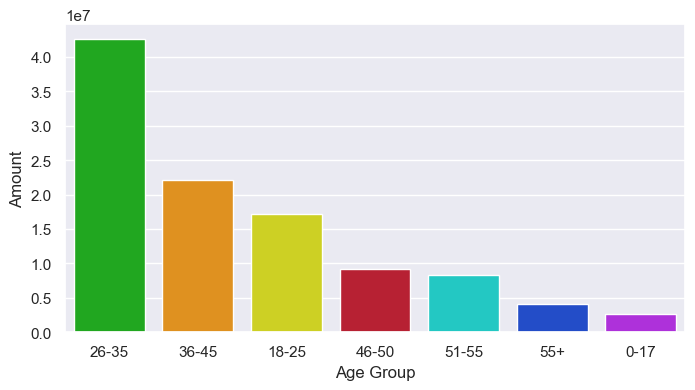

In [196]:
# Total Amount vs Age Group
colors= ['#0bbe09','#ff9700','#e8ec08','#d00820','#07e4dd', '#0740e4', '#bc15f6']
sns.set(rc={'figure.figsize': (8,4)})
sales_age = df.groupby(['Age Group'], as_index= False)['Amount'].sum().sort_values(by='Amount', ascending= False)
sns.barplot(x='Age Group', data= sales_age, y='Amount',hue= 'Age Group', palette= colors)

_**The graphs indicate that the majority of buyers are females within the 26–35 age group.**_

In [197]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [198]:
display(HTML("<h2>States</h2>"))

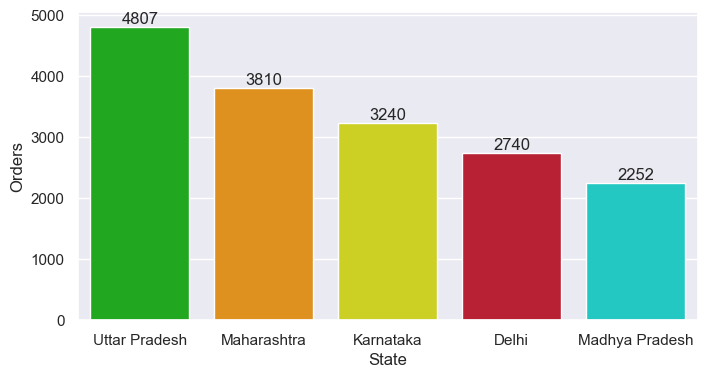

In [200]:
# Top 5 states based on Order
colors= ['#0bbe09','#ff9700','#e8ec08','#d00820','#07e4dd']

sales_state = df.groupby(['State'], as_index = False)['Orders'].sum().sort_values(by= 'Orders', ascending= False).head(5)

sns.set(rc={'figure.figsize':(8,4)})
ax = sns.barplot(data=sales_state, x= 'State', y= 'Orders', hue='State', palette= colors)

for bars in ax.containers:
    ax.bar_label(bars)    

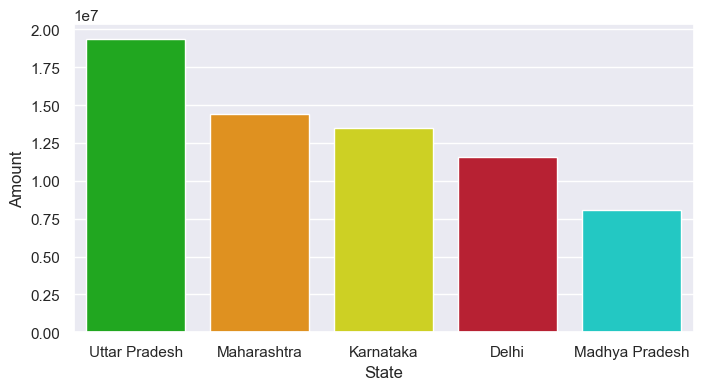

In [202]:
# Top 5 states based on Order
colors= ['#0bbe09','#ff9700','#e8ec08','#d00820','#07e4dd']

sales_state = df.groupby(['State'], as_index = False)['Amount'].sum().sort_values(by= 'Amount', ascending= False).head(5)

sns.set(rc={'figure.figsize':(8,4)})
ax = sns.barplot(data=sales_state, x= 'State', y= 'Amount', hue='State', palette= colors)

_**From above Graphs it is Clear that Uttar Pradesh, Maharashtra, Karnataka, Delhi, and Madhya Pradesh contribute the highest number of orders and sales revenue.**_

In [203]:
display(HTML("<h2>Marital Status</h2>"))

C:\Users\vivek\AppData\Local\Temp\ipykernel_18092\2517686886.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Married', 'Un-married'])


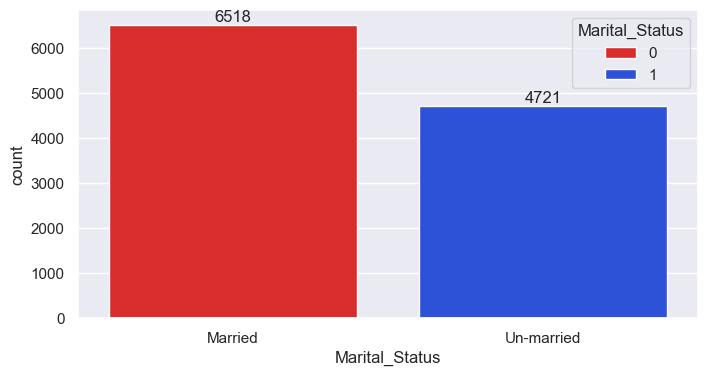

In [204]:
# Define color palette with numeric keys (correct mapping)
colors = {
    1: '#1141f3',  # Un-married
    0: '#f31111'   # Married
}
# Create the countplot without hue, using the correct palette
ax = sns.countplot(x='Marital_Status', data=df, palette=colors, hue= 'Marital_Status')
sns.set(rc={'figure.figsize': (7,5)})

# Set custom x-axis labels
ax.set_xticklabels(['Married', 'Un-married'])

# Add bar labels
for bars in ax.containers:
    ax.bar_label(bars)

C:\Users\vivek\AppData\Local\Temp\ipykernel_18092\3346405672.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Married', 'Un-married'])


[Text(0, 0, 'Married'), Text(1, 0, 'Un-married')]

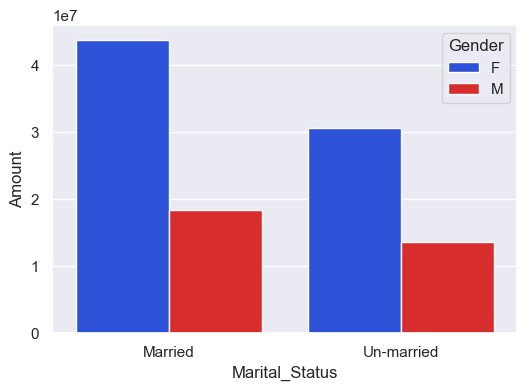

In [205]:
colors = {
    'F' : '#1141f3' ,
    'M' : '#f31111'
}

sales_mar = df.groupby(['Marital_Status', 'Gender'], as_index = False)['Amount'].sum().sort_values(by= 'Amount',ascending= False)
sns.set(rc={'figure.figsize':(6,4) })

ax = sns.barplot(x='Marital_Status',y='Amount', data= sales_mar, hue ='Gender', palette= colors)
ax.set_xticklabels(['Married', 'Un-married'])

_**Analysis of the graph suggests that most purchasers are married women.**_

In [206]:
display(HTML("<h2>Occupation</h2>"))

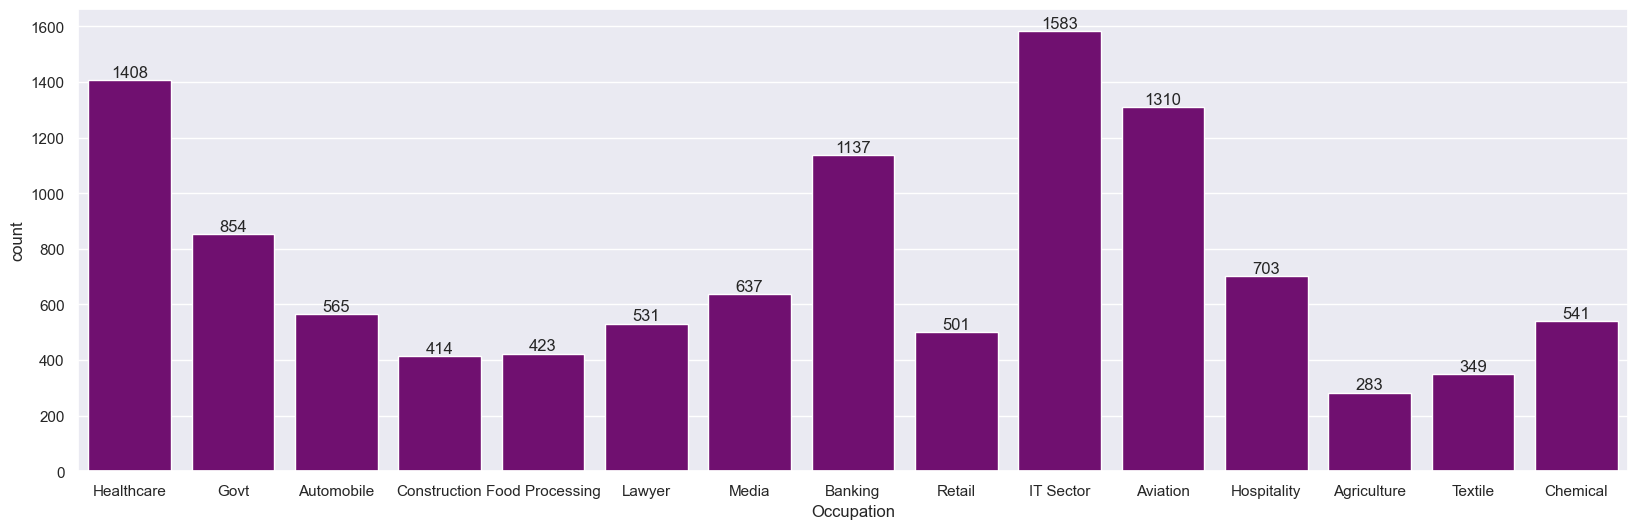

In [208]:
sns.set(rc={'figure.figsize': (20,6)})
ax = sns.countplot(x='Occupation', data= df, color= 'Purple')
for bars in ax.containers:
    ax.bar_label(bars)

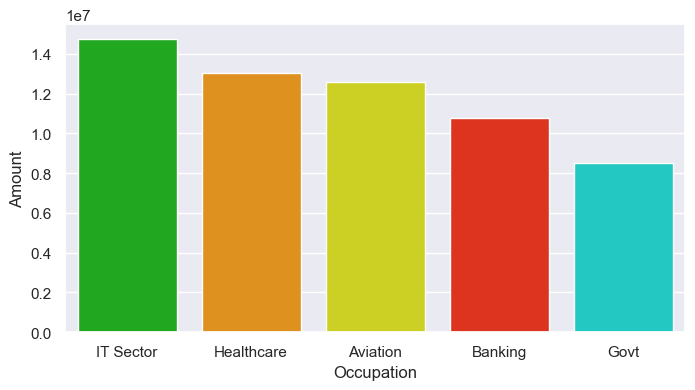

In [215]:
# Top 5 coustomer sectors sales by Occupation.
colors= ['#0bbe09','#ff9700','#e8ec08','#fd1b00','#07e4dd']
sns.set(rc={'figure.figsize': (8,4)})
sales_occupation = df.groupby(['Occupation'], as_index= False)['Amount'].sum().sort_values(by= 'Amount', ascending=False).head(5)
ax = sns.barplot(data= sales_occupation, x ='Occupation', y= 'Amount',hue ='Occupation', palette= colors)

_**According to the graph, a significant proportion of buyers work in the IT, healthcare, aviation, banking, and government sectors**_

In [216]:
display(HTML("<h2>Product Category</h2>"))

In [217]:
df.groupby(['Product_Category'], as_index= False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

,Product_Category,Amount
6,Food,33933883
3,Clothing & Apparel,16495019
5,Electronics & Gadgets,15643846
7,Footwear & Shoes,15575209
8,Furniture,5440051
9,Games & Toys,4331694
14,Sports Products,3635933
1,Beauty,1959484
0,Auto,1958609
15,Stationery,1676051


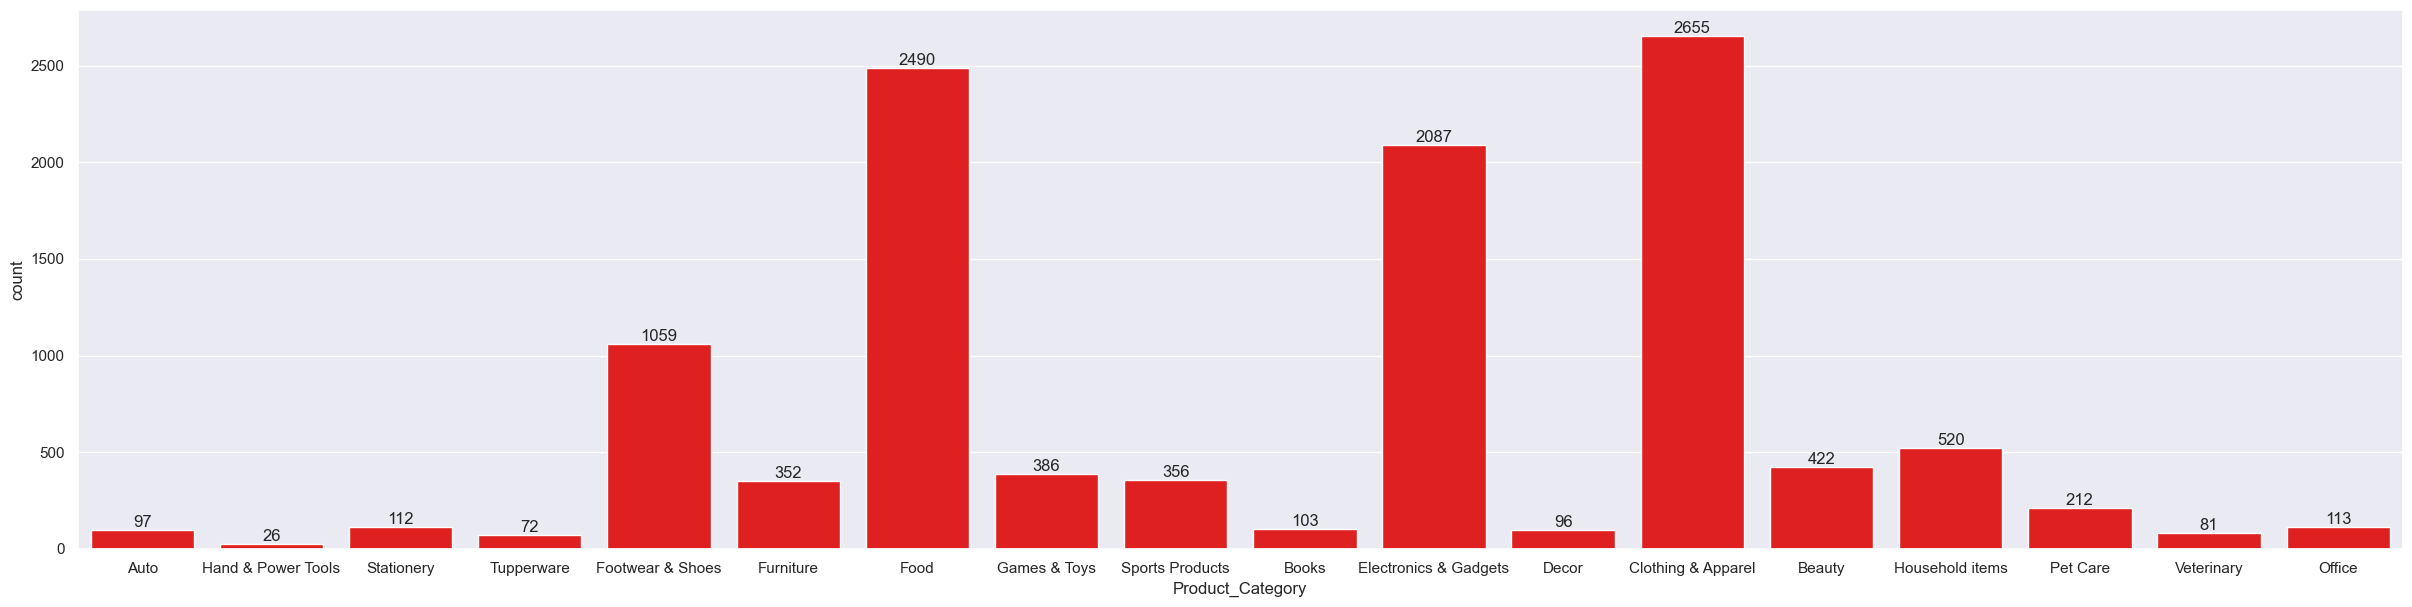

In [219]:
ax = sns.countplot(x='Product_Category', data = df, color= 'Red')
sns.set(rc={'figure.figsize':(30,7)})

for bars in ax.containers:
    ax.bar_label(bars)

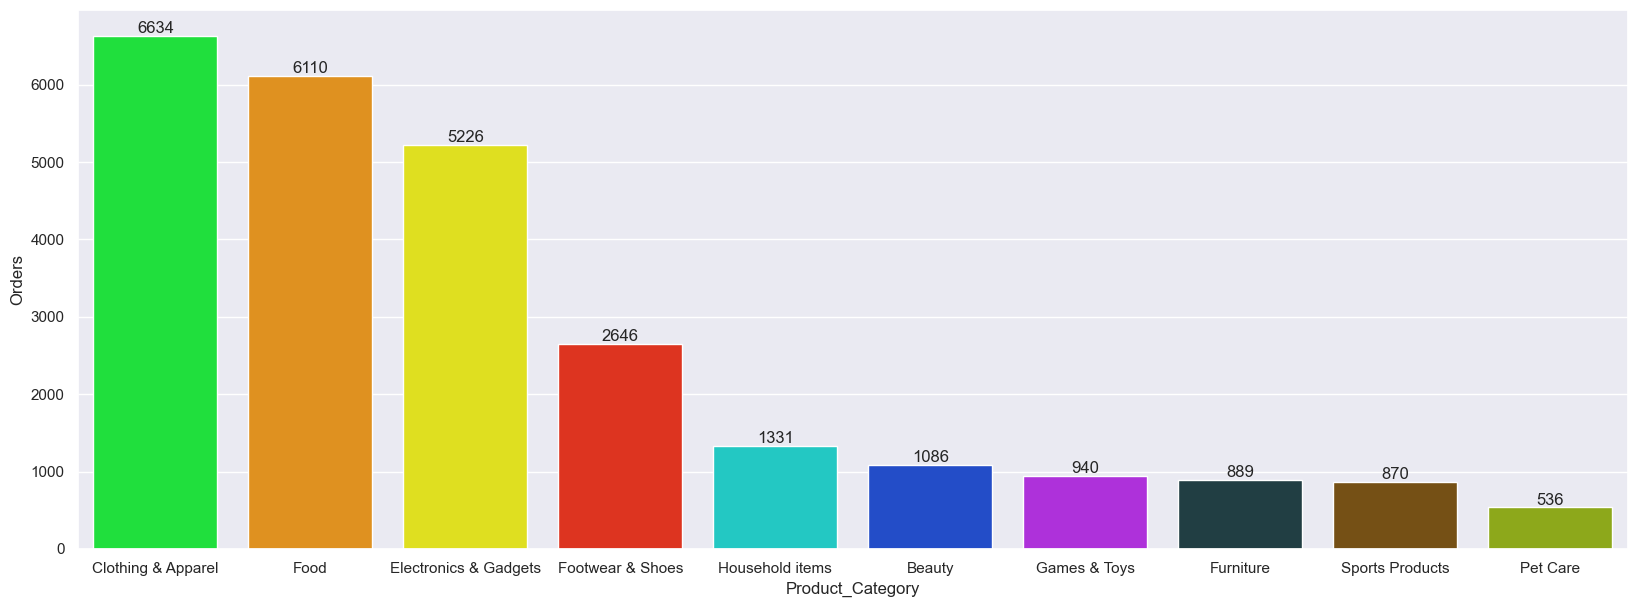

In [221]:
colors = ['#00ff27','#ff9700','#ffff00','#fd1b00','#07e4dd', '#0740e4', '#bc15f6','#1b4249', '#855305', '#9bc003']
Sales_by_product = df.groupby(['Product_Category'], as_index= False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)
sns.set(rc={'figure.figsize': (20,7)})
ax = sns.barplot(data=Sales_by_product, x= 'Product_Category',y='Orders', hue='Product_Category', palette= colors)
for bars in ax.containers:
    ax.bar_label(bars)

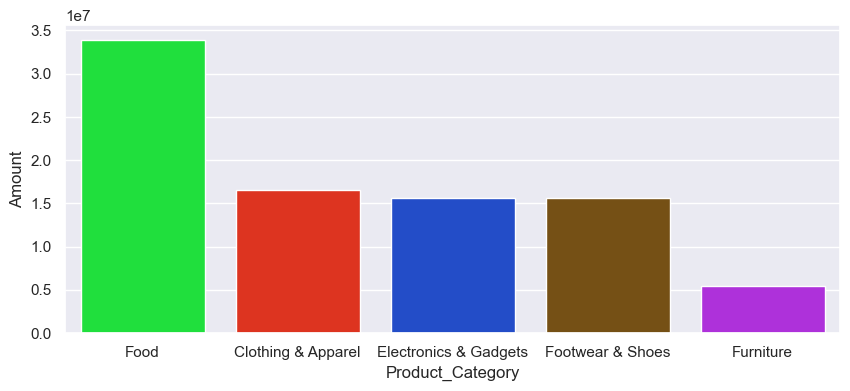

In [225]:
colors = ['#00ff27','#fd1b00','#0740e4', '#855305', '#bc15f6']
Sales_by_product = df.groupby(['Product_Category'], as_index= False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(5)
sns.set(rc={'figure.figsize': (10,4)})
ax = sns.barplot(data=Sales_by_product, x= 'Product_Category',y='Amount', hue='Product_Category', palette= colors)

_**The charts indicate that food, clothing, and electronic products are the most frequently purchased categories.**_

In [226]:
display(HTML("<h1>Conclusion :</h1>"))

_**The analysis reveals that married women aged 26–35 years, particularly from the states of Uttar Pradesh, Maharashtra, and Karnataka, are more likely to purchase products. These individuals are primarily employed in the IT, healthcare, and aviation sectors, and they tend to favor products in the food, clothing, and electronics categories. This insight highlights a clear consumer segment that can be strategically targeted for marketing and product positioning.**_